In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from datetime import datetime, timedelta
import datajoint as dj

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
dj.config.load("dj_local_conf_worker.json")
dj.conn()

[2026-01-15 11:57:23,632][INFO]: DataJoint is configured from c:\Users\Organoid PC\Documents\GitHub\utah_organoids\dj_local_conf_worker.json
[2026-01-15 11:57:24,033][INFO]: DataJoint 0.14.4 connected to utah-worker@db.datajoint.com:3306


DataJoint connection (connected) utah-worker@db.datajoint.com:3306

In [4]:
from workflow.pipeline import frame, culture, ephys, analysis, mua, probe

Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


# Select Experiment

In [5]:
organoid_id = "O09"
drug_name = "Control"

exp_key = {
    "organoid_id": organoid_id,
    "experiment_start_time": (culture.Experiment & f"organoid_id = '{organoid_id}'" & f"drug_name = '{drug_name}'").fetch1("experiment_start_time"),
}

culture.Experiment & exp_key

organoid_id e.g. O17,experiment_start_time,experiment_end_time,user,lineage_id de-identified code (e.g. hmau001),induction_culture_date,induction_culture_plate,post_induction_culture_date,post_induction_culture_plate,isolated_rosette_culture_date Date for isolating the rosette,isolated_rosette_culture_plate,organoid_culture_date,organoid_culture_plate,drug_name,drug_concentration concentration in uM,"experiment_plan e.g. mrna lysate, oct, protein lysate, or matrigel embedding, ephys, tracing"
O09,2023-05-03 17:33:00,2023-05-18 12:15:00,None,None,None,None,None,None,None,None,None,None,Control,nan,ephys


# Select Analysis Boundaries

In [6]:
boundary_start = exp_key["experiment_start_time"] + timedelta(hours=1)
boundary_end = boundary_start + timedelta(days=2)

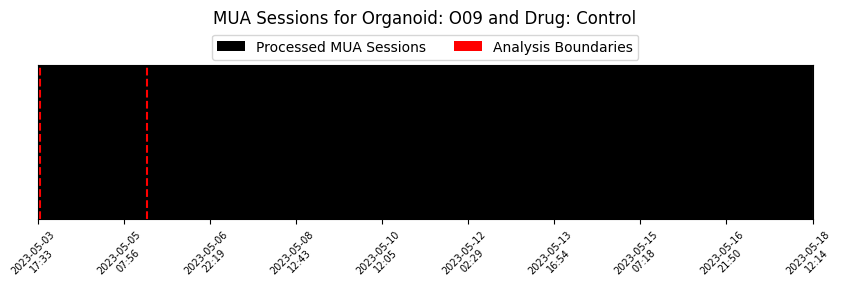

In [7]:
def downsample_to_length(x, n_new):

    """Downsample 1D array x to length n_new using linear interpolation."""
    new_idx = np.linspace(0, x.size - 1, n_new).astype(int)
    return x[new_idx]

# determine the experiment boundaries (based on exp_key)
experiment_start_time, experiment_end_time = (culture.Experiment & exp_key).fetch1("experiment_start_time", "experiment_end_time")

# find the available files within the experiment boundaries
file_times = (ephys.EphysRawFile & exp_key & f"file_time >= '{experiment_start_time}' AND file_time < '{experiment_end_time}'").fetch("file_time")

# find the processed MUA sessions within the experiment boundaries
processed_file_times = (mua.MUAEphysSession & exp_key & f"start_time >= '{experiment_start_time}' AND start_time < '{experiment_end_time}'").fetch("start_time")

# create a visualization of the data already processed for the given exp_key
fig = plt.figure(figsize=(10, 2))
ax = fig.gca()

processed_bool = np.isin(file_times, processed_file_times)
ax.imshow(processed_bool[np.newaxis, :], aspect="auto", cmap="binary")

# plot manually selected boundaries as red vertical lines
start_x = np.searchsorted(file_times, boundary_start)
end_x = np.searchsorted(file_times, boundary_end)
ax.axvline(start_x, color="red", linestyle="--", label="Analysis Boundaries")
ax.axvline(end_x, color="red", linestyle="--")

xticks = [d.strftime('%Y-%m-%d\n%H:%M') for d in downsample_to_length(file_times, 10)]
ax.set_xticks(np.linspace(0, len(file_times) - 1, 10))
ax.set_xticklabels(xticks, rotation=45, fontsize=7)
ax.set_yticks([])

ax.set_title(f"MUA Sessions for Organoid: {organoid_id} and Drug: {drug_name}", pad=30)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='black', label='Processed MUA Sessions'), Patch(facecolor='red', label='Analysis Boundaries')]
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 2.1),
    borderaxespad=10,
    ncol=2
)

plt.show()

In [8]:
# Check if all files within the selected boundaries have been processed
analysis_files = file_times[(file_times >= boundary_start) & (file_times <= boundary_end)]

if all(np.isin(analysis_files, processed_file_times)):
    print("All files within the selected boundaries have been processed.")
else:
    print(f"{len(analysis_files) - np.sum(np.isin(analysis_files, processed_file_times))} Files within the selected boundaries are yet to be processed.")

All files within the selected boundaries have been processed.


# Select Parameters for Frame Analysis

In [9]:
frame.TimeFrameParamset()

frame_param_idx Unique identifier for the frame parameter set,num_frames Number of frames to extract,min_per_frame Length of each frame in minutes
1,12,5
2,4,15
3,8,15
4,24,15


Optional: Create Parameterset

In [10]:
insert_key = {
    "frame_param_idx": 4,
    "num_frames": 24,
    "min_per_frame": 15
}

frame.TimeFrameParamset().insert1(insert_key, skip_duplicates=True)

## Insert New Frame Analysis Session

In [11]:
key = {
    **exp_key,
    "start_boundary": boundary_start,
    "end_boundary": boundary_end,
    "frame_param_idx": 4
}

frame.FrameSession.insert1(key, skip_duplicates=True)
frame.FrameSession() & key

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4


In [12]:
frame.FrameAnalysis.populate()
frame.FrameAnalysis.ActiveTimeFrames & key

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset,frame_start Start of active time frame,frame_end End of active time frame,frame_firing_rate Firing rates for each frame
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 19:00:49,2023-05-03 19:15:49,0.360815
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 19:17:49,2023-05-03 19:32:49,0.550222
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 19:40:49,2023-05-03 19:55:49,0.854222
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 19:55:49,2023-05-03 20:10:49,0.833852
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 20:11:49,2023-05-03 20:26:49,0.768963
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 20:35:49,2023-05-03 20:50:49,1.63296
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 20:58:49,2023-05-03 21:13:49,0.187778
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 21:26:49,2023-05-03 21:41:49,0.117778
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 21:45:49,2023-05-03 22:00:49,0.17037
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2023-05-03 22:00:49,2023-05-03 22:15:49,0.0925926


# Inspect Extracted Active Time Frames

In [13]:
# Fetch MUA Firing Rates Between Boundaries
start_times, spike_rates = (mua.MUASpikes.Channel & key & f"start_time BETWEEN '{boundary_start}' AND '{boundary_end}'").fetch("start_time", "spike_rate")  

# Create population firing vector (sum spike rates across channels)
time_vector = np.arange(min(start_times), max(start_times), timedelta(minutes=1)).astype('datetime64[m]')

start_times_dt64 = start_times.astype('datetime64[m]')
population_firing_vector = np.zeros_like(time_vector, dtype=float)
for t in time_vector:

    time_bool = start_times_dt64 == t
    population_firing_vector[np.where(time_vector == t)[0][0]] = np.sum(spike_rates[time_bool])

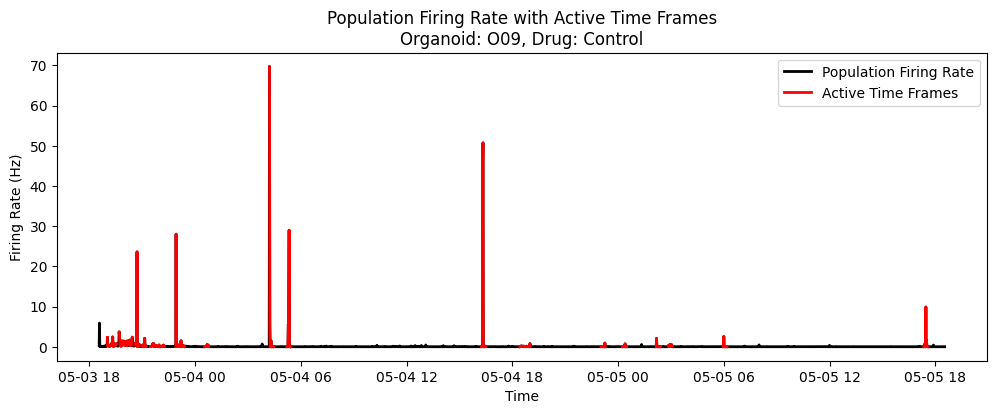

In [14]:
# Extract Active Time Frames (sorted by firing rate)
frame_start, frame_end = (frame.FrameAnalysis.ActiveTimeFrames & key).fetch("frame_start", "frame_end", order_by="frame_firing_rate DESC")

# Plot Population Firing Rate with Active Time Frames Highlighted in Red
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_vector, population_firing_vector, label="Population Firing Rate", color="black", linewidth=2)
for start, end in zip(frame_start, frame_end):
    active_time_mask = (start <= time_vector) & (time_vector <= end)
    ax.plot(time_vector[active_time_mask], population_firing_vector[active_time_mask], color="red", linewidth=2)
ax.plot([], [], color="red", label="Active Time Frames", linewidth=2)  # Dummy line for legend
ax.set_xlabel("Time")
ax.set_ylabel("Firing Rate (Hz)")
ax.set_title(f"Population Firing Rate with Active Time Frames\nOrganoid: {organoid_id}, Drug: {drug_name}")
ax.legend()
plt.show()

## Insert Analysis Tables based on Active Time Frames

In [15]:
# For this test run, we will only insert 1 time frame
start_time = frame_start[0]
end_time = frame_end[0]

ephys_key = {
    **exp_key,
    "insertion_number": 0,
    "start_time": start_time,
    "end_time": end_time,
    "session_type": 'both'
}
probe_key = {
    **exp_key,
    "insertion_number": 0,
    "start_time": start_time,
    "end_time": end_time,
    "probe": 'Q983',
    "port_id": "A",
    "used_electrodes": []
}

In [16]:
ephys.EphysSession.insert1(ephys_key, skip_duplicates=True)
ephys.EphysSessionProbe.insert1(probe_key, skip_duplicates=True)

key = (ephys.EphysSession & ephys_key).fetch1("KEY")
ephys.EphysSession() & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,session_type
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,both


In [17]:
cluster_key = {
    **key,
    "paramset_idx": 401
}

ephys.ClusteringTask.insert1(cluster_key, skip_duplicates=True)
ephys.ClusteringTask() & cluster_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,paramset_idx,clustering_output_dir clustering output directory relative to the clustering root data directory
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,401,O09-12_raw/202305040412_202305040427/O09/kilosort4_401


In [18]:
frame.BurstDetectionParamset()

burst_param_idx Unique identifier for the burst detection parameter set,gaus_len_ms Gaussian kernel length in milliseconds,boxcar_len_ms Boxcar kernel length in milliseconds,detection_threshold Threshold for burst detection in standard deviations,min_distance_ms Minimum distance between bursts in milliseconds
1,100,20,2.0,1000.0


In [19]:
burst_key = {
    **key,
    "burst_param_idx": 1
}

frame.BurstSession.insert1(burst_key, skip_duplicates=True)
frame.BurstSession() & burst_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,burst_param_idx Unique identifier for the burst detection parameter set
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,1


In [20]:
ephys.ClusteringTask & cluster_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,paramset_idx,clustering_output_dir clustering output directory relative to the clustering root data directory
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,401,O09-12_raw/202305040412_202305040427/O09/kilosort4_401


In [21]:
print(key)

{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 0, 'start_time': datetime.datetime(2023, 5, 4, 4, 12, 52), 'end_time': datetime.datetime(2023, 5, 4, 4, 27, 52)}


In [22]:
analysis.SpectrogramParameters()

param_idx,window_size Time in seconds,overlap_size Time in seconds,description
0,2.0,1.0,"2s window, 50% overlap (delta, theta, alpha)"
1,0.5,0.25,"0.5s window, 50% overlap (beta, gamma)"
2,0.25,0.125,"0.25s window, 50% overlap (high-gamma)"


In [23]:
trace_keys = (ephys.LFP.Trace & key).fetch("KEY")
spectrogram_keys = [{**tkey, "param_idx": 2} for tkey in trace_keys]

In [24]:
analysis.LFPSpectrogram.populate(spectrogram_keys)

{'success_count': 0, 'error_list': []}

In [25]:
ephys.EphysSessionProbe() & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,probe unique identifier for this model of probe (e.g. serial number),port_id,"used_electrodes list of electrode IDs used in this session (if null, all electrodes are used)"
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,Q983,A,=BLOB=


In [26]:
frame.Coherence.populate(key)

{'success_count': 0, 'error_list': []}

In [27]:
frame.FOOOFParamset()

fooof_param_idx Unique identifier for the FOOOF parameter set,"peak_width_limits Lower and upper bounds on peak widths in Hz. e.g. [1, 12]",max_n_peaks Maximum number of peaks the model can fit. e.g. 6,min_peak_height Minimum absolute height of a peak above the aperiodic component. e.g. 0.1,peak_threshold Relative threshold that candidate peaks must exceed to be included. e.g. 2.0,"aperiodic_mode Form of the aperiodic fit. e.g. 'fixed', 'knee'"
0,=BLOB=,6,0.1,2.0,fixed
1,=BLOB=,3,0.05,3.5,fixed


In [28]:
fooof_key = {
    **key,
    "fooof_param_idx": 1,
    "start_freq": 2.0,
    "end_freq": 200.0,
    "analysis_electrodes": []
}
frame.FOOOFSession.insert1(fooof_key, skip_duplicates=True)
frame.FOOOFSession & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,fooof_param_idx Unique identifier for the FOOOF parameter set,start_freq Start frequency for FOOOF fitting,end_freq End frequency for FOOOF fitting,analysis_electrodes List of electrodes to perform FOOOF analysis on (will be averaged)
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,1,2.0,200.0,=BLOB=


In [30]:
frame.FOOOFAnalysis.populate()
frame.FOOOFAnalysis & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,fooof_param_idx Unique identifier for the FOOOF parameter set,start_freq Start frequency for FOOOF fitting,end_freq End frequency for FOOOF fitting,spec_param_idx Reference to SpectrogramParamset,plot Plot of FOOOF fit (as json),aperiodic_offset Aperiodic offset,aperiodic_knee Aperiodic knee,aperiodic_exponent Aperiodic exponent,peak_center_frequencies Center frequencies of detected peaks,peak_powers Power of detected peaks (above aperiodic fit),peak_bandwidths Bandwidths of detected peaks,error Error of FOOOF fit (RMSE),r_squared R^2 of FOOOF fit
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,1,2.0,200.0,2,=BLOB=,4.41604,0.0,2.01408,=BLOB=,=BLOB=,=BLOB=,0.071174,0.98677


In [33]:
frame.STTFA.populate(spectrogram_keys)

{'success_count': 32, 'error_list': []}

In [34]:
print(key)

{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 0, 'start_time': datetime.datetime(2023, 5, 4, 4, 12, 52), 'end_time': datetime.datetime(2023, 5, 4, 4, 27, 52)}
